In [1]:
from sklearn.datasets import make_regression
from sklearn.isotonic import IsotonicRegression
X, y = make_regression(n_samples=10, n_features=1, random_state=41)
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import numpy as np
import os
import sys

module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path)

In [3]:
from binning_process.core.utils import quantile_cuts

In [4]:
import pandas as pd
df  = pd.read_csv(r"D:\Data\f88_bscore_v4\data\Data_Sets_15\20251030_Train_Data_15.csv")


In [5]:
X = df['min_trans_in_3month']
y = df['FlagTarget_B4+@9M']

In [51]:
init_cuts = quantile_cuts(X, 20)
edges     = [-np.inf] + init_cuts + [np.inf]
bin_idx   = pd.cut(X, bins=edges, labels=False, right=True, include_lowest=True)

centers, rates, weights = [], [], []
for i in range(len(edges) - 1):
    mask = bin_idx == i
    if mask.sum() == 0:
        continue
    centers.append(float(np.median(X[mask])))
    rates.append(float(y[mask].mean()))
    weights.append(int(mask.sum()))

centers = np.array(centers)
rates   = np.array(rates)
weights = np.array(weights)

<Axes: >

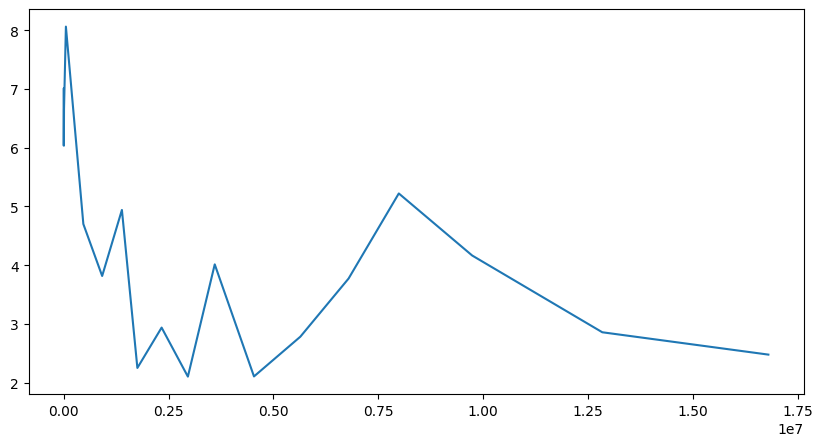

In [52]:
plt.figure(figsize=(10, 5))
sns.lineplot(x=centers, y=rates*100)

In [53]:
iso = IsotonicRegression(
        increasing=False,
        out_of_bounds="clip")

<Axes: >

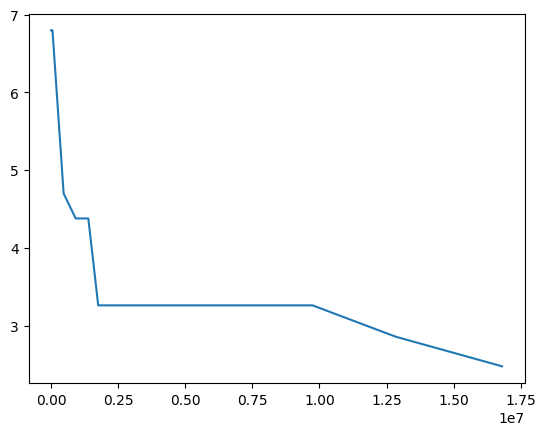

In [54]:
fitted = iso.fit_transform(centers, rates, sample_weight=weights)
sns.lineplot(x=centers, y=fitted*100)

In [55]:
# Nếu muốn lấy luôn điểm cuối của phía sau (bin sau), thay vì lấy điểm ở giữa 2 median (boundary),
# ta có thể dùng chính init_cuts để lấy cut-point cho bin phía sau.
cuts = []
for i in range(len(fitted) - 1):
    print("centers[i], centers[i+1]", centers[i], centers[i+1])
    print("fitted[i], fitted[i+1]", fitted[i], fitted[i+1])
    print("init_cuts[i]", init_cuts[i])
    if abs(fitted[i] - fitted[i + 1]) > 1e-9:
        # Lấy init_cuts[i] tương ứng với cạnh phải của bin i
        if i < len(init_cuts):
            cuts.append(float(init_cuts[i]))


centers[i], centers[i+1] 1000.0 1230.0
fitted[i], fitted[i+1] 0.06799282569704876 0.06799282569704876
init_cuts[i] 1099.0
centers[i], centers[i+1] 1230.0 1558.5
fitted[i], fitted[i+1] 0.06799282569704876 0.06799282569704876
init_cuts[i] 1368.0
centers[i], centers[i+1] 1558.5 2165.0
fitted[i], fitted[i+1] 0.06799282569704876 0.06799282569704876
init_cuts[i] 1780.0
centers[i], centers[i+1] 2165.0 5496.0
fitted[i], fitted[i+1] 0.06799282569704876 0.06799282569704876
init_cuts[i] 3062.0
centers[i], centers[i+1] 5496.0 50497.5
fitted[i], fitted[i+1] 0.06799282569704876 0.06799282569704876
init_cuts[i] 14466.0
centers[i], centers[i+1] 50497.5 466498.0
fitted[i], fitted[i+1] 0.06799282569704876 0.04701273261508325
init_cuts[i] 211763.0
centers[i], centers[i+1] 466498.0 915128.0
fitted[i], fitted[i+1] 0.04701273261508325 0.0437866927592955
init_cuts[i] 702781.0
centers[i], centers[i+1] 915128.0 1386000.0
fitted[i], fitted[i+1] 0.0437866927592955 0.0437866927592955
init_cuts[i] 1116122.0
center

In [56]:
cuts

[211763.0, 702781.0, 1535004.0, 11320738.0, 13315068.0]

In [33]:
cuts

[131820.0, 311932.0, 416000.0, 603426.0, 1535004.0, 11320730.0, 13210347.0]